# Practical Regression Assignments - Python Scripts

# 1. Write a Python script to visualize the distribution of errors (residuals) for a multiple linear regression model using Seaborn's "diamonds" dataset.


In [12]:
# 1. Visualize the distribution of residuals using Seaborn's 'diamonds' dataset

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load the diamonds dataset
diamonds = sns.load_dataset('diamonds')



In [13]:
# Keep only numeric columns (drop categorical features)
numeric_diamonds = diamonds.select_dtypes(include=['float64', 'int64'])



In [14]:
# Drop missing values (if any)
numeric_diamonds.dropna(inplace=True)




In [15]:
# Features (X) and target (y)
X = numeric_diamonds.drop('price', axis=1)
y = numeric_diamonds['price']



In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred



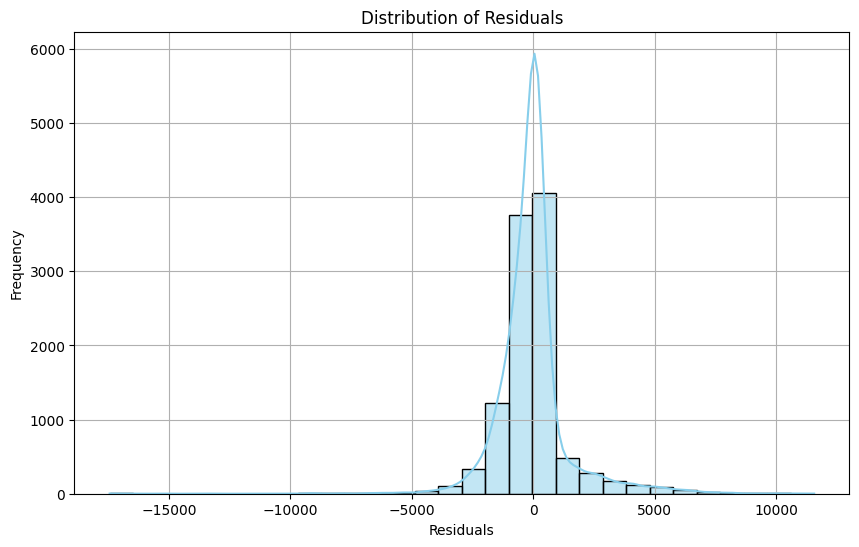

In [17]:
# Plot the residual distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 2. Write a Python script to calculate and print Mean Squared Error (MSE), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) for a linear regression model.

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load diamonds dataset
diamonds = sns.load_dataset('diamonds')


In [19]:
# Keep only numeric columns (exclude categorical features)
numeric_diamonds = diamonds.select_dtypes(include=['float64', 'int64']).dropna()

# Define features and target
X = numeric_diamonds.drop('price', axis=1)
y = numeric_diamonds['price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [20]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)


In [21]:
# Print results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Squared Error (MSE): 2242178.90
Mean Absolute Error (MAE): 888.48
Root Mean Squared Error (RMSE): 1497.39


# 3. Write a Python script to check if the assumptions of linear regression are met. Use a scatter plot to check linearity, residuals plot for homoscedasticity, and correlation matrix for multicollinearity.


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

In [23]:
# Keep only numeric features
df = diamonds.select_dtypes(include=["float64", "int64"]).dropna()

# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# Fit Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred


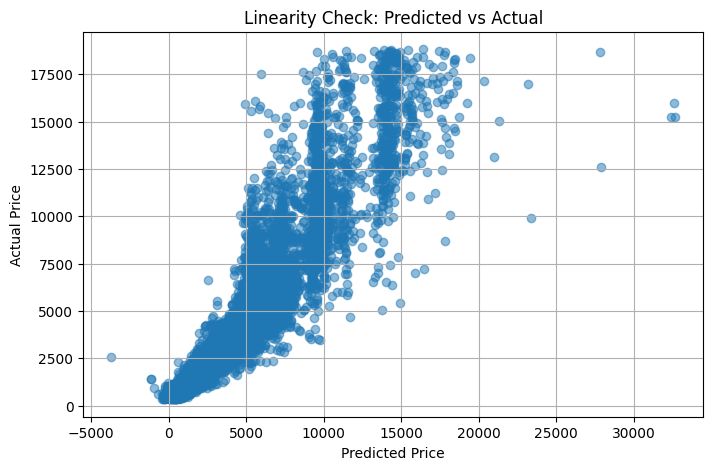

In [25]:
# 1. Linearity: Plot predicted vs actual
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.title("Linearity Check: Predicted vs Actual")
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.grid(True)
plt.show()


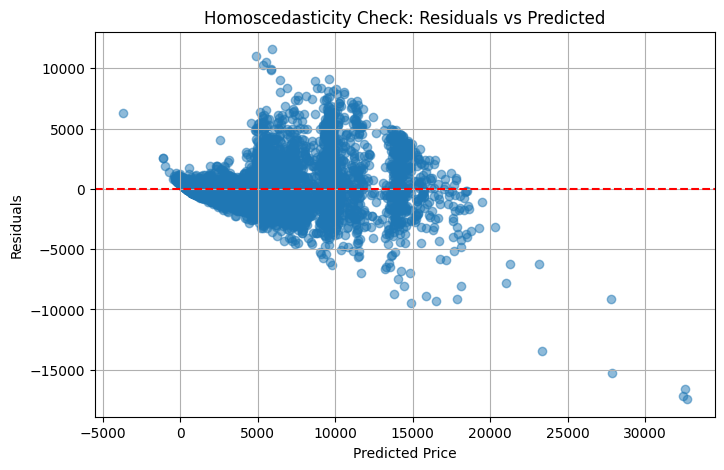

In [26]:
# 2. Homoscedasticity: Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Homoscedasticity Check: Residuals vs Predicted")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()


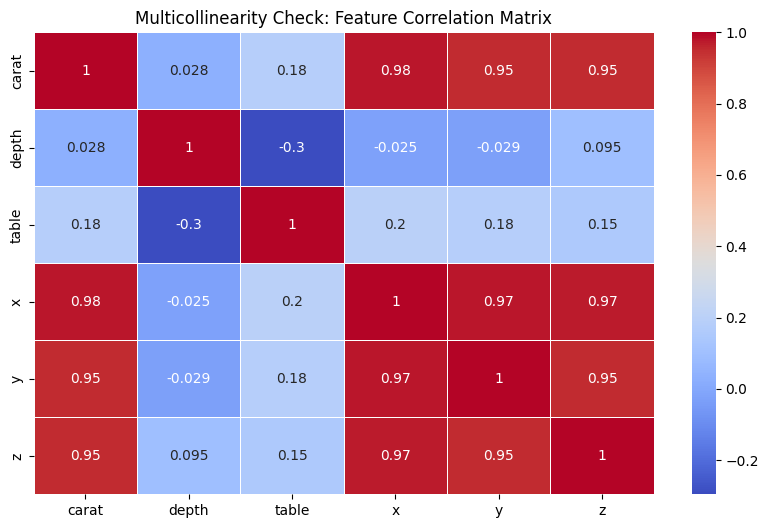

In [27]:
# 3. Multicollinearity: Correlation matrix
plt.figure(figsize=(10, 6))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Multicollinearity Check: Feature Correlation Matrix")
plt.show()

# 4. Write a Python script that creates a machine learning pipeline with feature scaling and evaluates the performance of different regression models.

In [28]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score
import numpy as np

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

In [29]:
# Keep only numeric columns
df = diamonds.select_dtypes(include=["float64", "int64"]).dropna()

# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Define models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

In [31]:
# Evaluate each model using pipeline
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: R² Score = {r2:.4f}")

Linear Regression: R² Score = 0.8590
Ridge Regression: R² Score = 0.8590
Lasso Regression: R² Score = 0.8590


# 5. Implement a simple linear regression model on a dataset and print the model's coefficients, intercept, and R-squared score.

In [32]:
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

In [33]:
# Use only 'carat' as the predictor and 'price' as the target
X = diamonds[['carat']]
y = diamonds['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit simple linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [34]:
# Print model parameters
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

Coefficient (slope): 7768.9105
Intercept: -2261.9117
R-squared Score: 0.8489


# 6. Write a Python script that analyzes the relationship between total bill and tip in the 'tips' dataset using simple linear regression and visualizes the results.

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the 'tips' dataset
tips = sns.load_dataset("tips")

In [36]:
# Define features and target
X = tips[['total_bill']]
y = tips['tip']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict tips
y_pred = model.predict(X_test)

In [37]:
# Print model parameters
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

Coefficient (slope): 0.1070
Intercept: 0.9252
R² Score: 0.5449


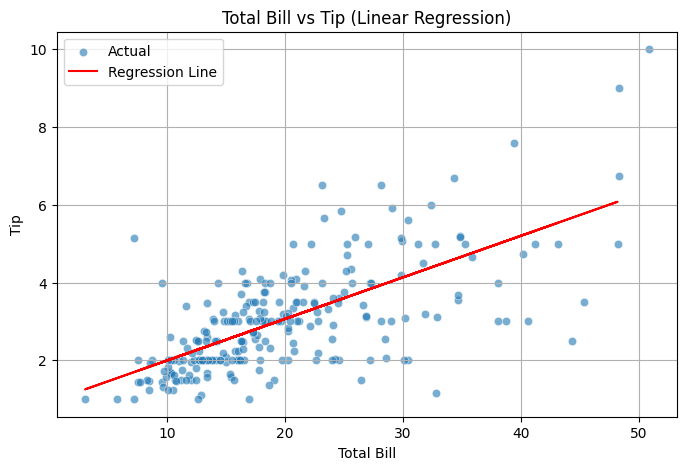

In [38]:
# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', label='Actual', alpha=0.6)
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.title('Total Bill vs Tip (Linear Regression)')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.legend()
plt.grid(True)
plt.show()

# 7. Write a Python script that fits a linear regression model to a synthetic dataset with one feature. Use the model to predict new values and plot the data points along with the regression line.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3x + noise

In [40]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [41]:
# Print model parameters
print(f"Coefficient (slope): {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

Coefficient (slope): 2.7993
Intercept: 4.1429


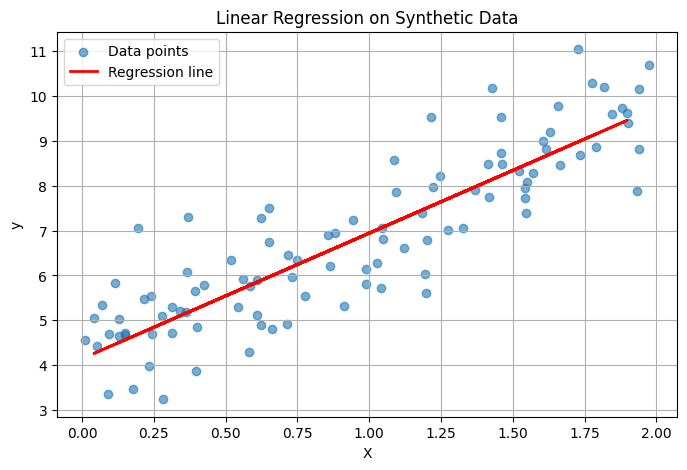

In [42]:
# Plot the data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Data points", alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Regression line")
plt.title("Linear Regression on Synthetic Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 8. Write a Python script that pickles a trained linear regression model and saves it to a file.

In [43]:
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 5 + 2 * X + np.random.randn(100, 1)

In [44]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
# Save model using pickle
with open("linear_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [46]:
print("Model has been saved to 'linear_model.pkl'.")

Model has been saved to 'linear_model.pkl'.


# 9. Write a Python script that fits a polynomial regression model (degree 2) to a dataset and plots the regression curve.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + 2 * X**2 + np.random.randn(100, 1)

In [48]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)

# Predict using the model
X_range = np.linspace(0, 2, 100).reshape(100, 1)
X_range_poly = poly.transform(X_range)
y_pred = model.predict(X_range_poly)

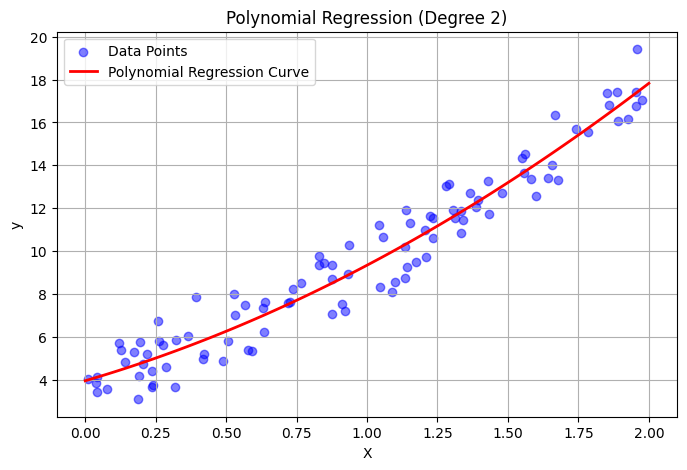

In [49]:
# Plot original data and regression curve
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')
plt.plot(X_range, y_pred, color='red', linewidth=2, label='Polynomial Regression Curve')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 10. Generate synthetic data for simple linear regression (use random values for X and y) and fit a linear regression model to the data. Print the model's coefficient and intercept.

In [50]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(42)
X = 3 * np.random.rand(100, 1)
y = 7 + 2.5 * X + np.random.randn(100, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [51]:
# Print model parameters
print(f"Coefficient (slope): {model.coef_[0][0]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

Coefficient (slope): 2.3467
Intercept: 7.2151


# 11. Write a Python script that fits polynomial regression models of different degrees to a synthetic dataset and compares their performance.

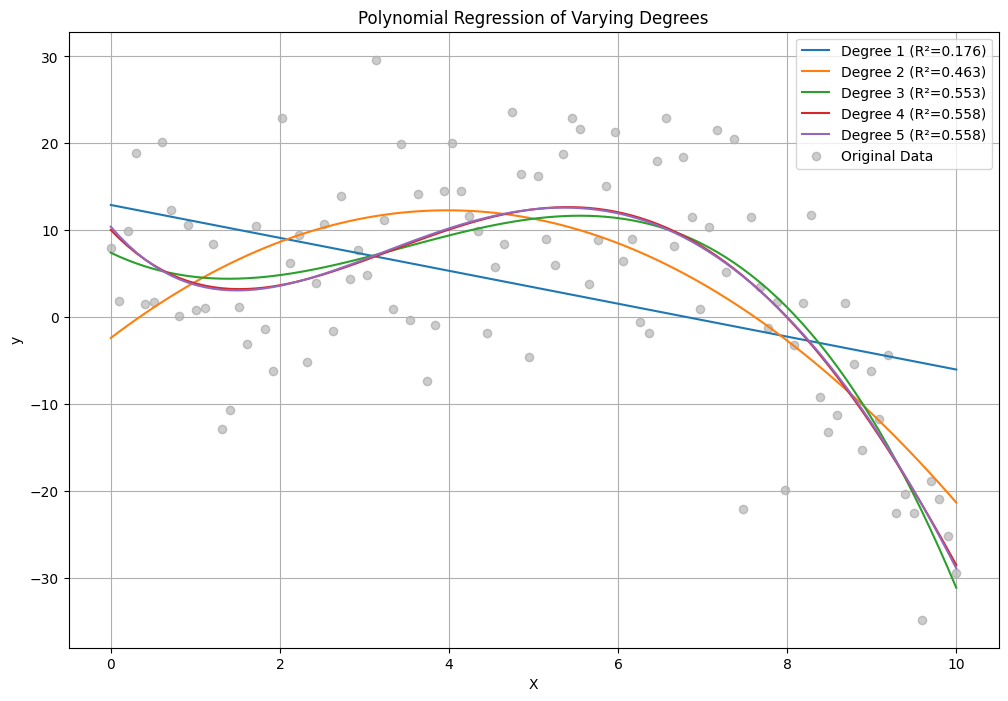

Degree 1 Polynomial - R² Score: 0.1762
Degree 2 Polynomial - R² Score: 0.4635
Degree 3 Polynomial - R² Score: 0.5530
Degree 4 Polynomial - R² Score: 0.5583
Degree 5 Polynomial - R² Score: 0.5584


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 + 2 * X + 0.5 * X**2 - 0.1 * X**3 + np.random.randn(100, 1) * 10

# Test polynomial degrees from 1 to 5
degrees = [1, 2, 3, 4, 5]
r2_scores = []

plt.figure(figsize=(12, 8))
for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    # Fit model
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)

    # Calculate and store R² score
    r2 = r2_score(y, y_pred)
    r2_scores.append(r2)

    # Plot
    plt.plot(X, y_pred, label=f'Degree {degree} (R²={r2:.3f})')

# Scatter original data
plt.scatter(X, y, color='gray', alpha=0.4, label='Original Data')
plt.title('Polynomial Regression of Varying Degrees')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Print R² scores
for deg, score in zip(degrees, r2_scores):
    print(f"Degree {deg} Polynomial - R² Score: {score:.4f}")

# 12. Write a Python script that fits a simple linear regression model with two features and prints the model's coefficients, intercept, and R-squared score.

In [58]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the 'diamonds' dataset
diamonds = sns.load_dataset("diamonds")

# Select two numerical features and the target
features = diamonds[['carat', 'depth']]  # Two predictors
target = diamonds['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

In [59]:
# Output results
print("Model Coefficients:")
print(f"carat: {model.coef_[0]:.4f}")
print(f"depth: {model.coef_[1]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

Model Coefficients:
carat: 7778.7412
depth: -99.7769
Intercept: 3890.7717
R² Score: 0.8506


# 13. Write a Python script that generates synthetic data, fits a linear regression model, and visualizes the regression line along with the data points.

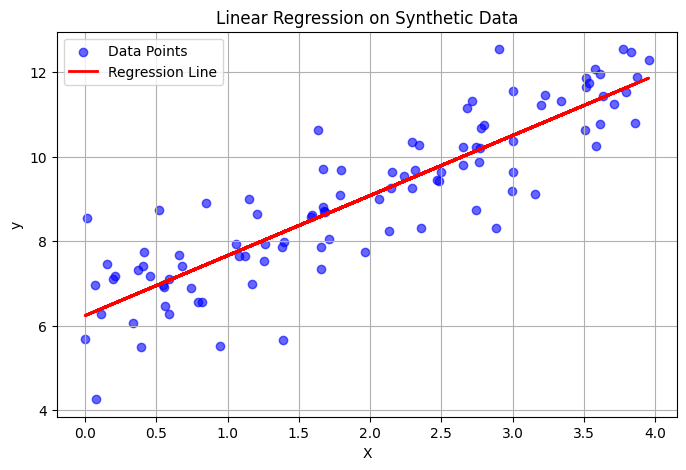

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic data
np.random.seed(1)
X = 4 * np.random.rand(100, 1)
y = 6 + 1.5 * X + np.random.randn(100, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Plot the data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression on Synthetic Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 14. Write a Python script that uses the Variance Inflation Factor (VIF) to check for multicollinearity in a dataset with multiple features.

In [65]:
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

# Use only numerical features
df = diamonds.select_dtypes(include=["float64", "int64"]).dropna()

# Add constant for VIF calculation
X = add_constant(df.drop("price", axis=1))  # Exclude target variable

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data)

Variance Inflation Factor (VIF) for each feature:
  Feature          VIF
0   const  4821.696350
1   carat    21.602712
2   depth     1.496590
3   table     1.143225
4       x    56.187704
5       y    20.454295
6       z    23.530049


# 15. Write a Python script that generates synthetic data for a polynomial relationship (degree 4), fits a polynomial regression model, and plots the regression curve.

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 1 + 0.5 * X - X**2 + 0.2 * X**3 + 0.05 * X**4 + np.random.randn(100, 1)

# Transform features to polynomial degree 4
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

# Fit polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

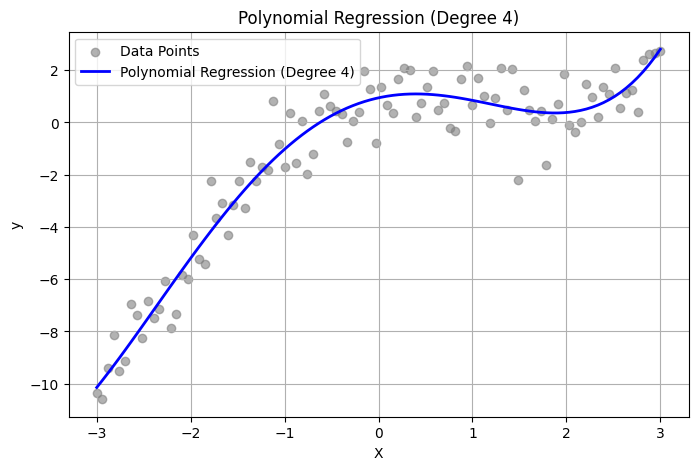

In [67]:
# Plot the original data and the polynomial regression curve
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', alpha=0.6, label='Data Points')
plt.plot(X, y_pred, color='blue', linewidth=2, label='Polynomial Regression (Degree 4)')
plt.title('Polynomial Regression (Degree 4)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 16. Write a Python script that creates a machine learning pipeline with data standardization and a multiple linear regression model, and prints the R-squared score.

In [69]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

# Use only numeric features
df = diamonds.select_dtypes(include=["float64", "int64"]).dropna()

# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define pipeline with standardization and linear regression
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")

R-squared Score: 0.8590


# 17. Write a Python script that performs polynomial regression (degree 3) on a synthetic dataset and plots the regression curve.

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic data
np.random.seed(0)
X = np.linspace(-2, 2, 100).reshape(-1, 1)
y = 3 + 2 * X - X**2 + 0.5 * X**3 + np.random.randn(100, 1)

# Transform to polynomial features of degree 3
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Fit polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)
y_pred = model.predict(X_poly)

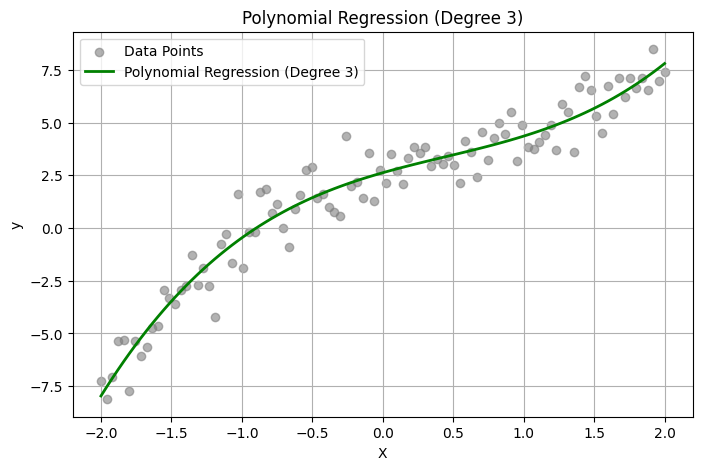

In [72]:
# Plot the results
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='gray', alpha=0.6, label='Data Points')
plt.plot(X, y_pred, color='green', linewidth=2, label='Polynomial Regression (Degree 3)')
plt.title('Polynomial Regression (Degree 3)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 18. Write a Python script that performs multiple linear regression on a synthetic dataset with 5 features. Print the R-squared score and model coefficients.

In [76]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 5)  # 100 samples, 5 features
true_coefs = [1.5, -2.0, 3.0, 0.5, -1.0]
y = X @ np.array(true_coefs) + np.random.randn(100)  # Add noise

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit multiple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

In [77]:
# Output results
print(f"R-squared Score: {r2:.4f}")
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R-squared Score: 0.4173
Model Coefficients: [ 1.15295867 -2.23392333  3.64790329  0.6455846  -1.44564017]
Intercept: 0.1459847439869867


# 19. Write a Python script that generates synthetic data for linear regression, fits a model, and visualizes the data points along with the regression line.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generate synthetic linear data
np.random.seed(0)
X = 5 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # Linear relationship with noise

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

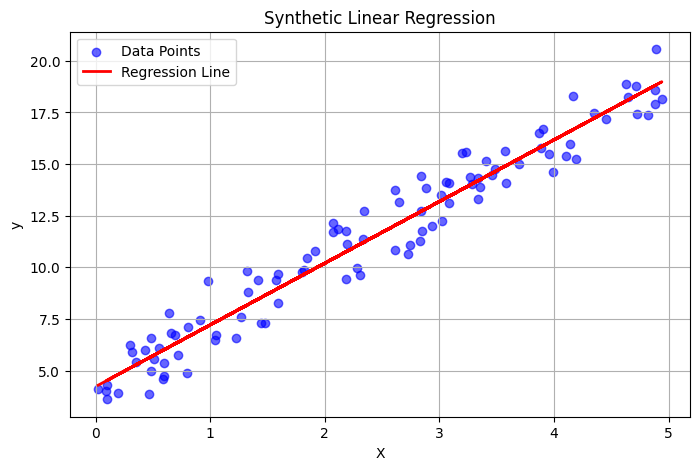

In [79]:
# Plot data and regression line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Synthetic Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 20. Create a synthetic dataset with 3 features and perform multiple linear regression. Print the model's R-squared score and coefficients.

In [80]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic dataset
np.random.seed(1)
X = np.random.rand(100, 3)  # 100 samples, 3 features
true_coefficients = [2.0, -1.5, 0.5]
y = X @ np.array(true_coefficients) + np.random.randn(100)  # Add noise

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Output results
print(f"R-squared Score: {r2:.4f}")
print("Model Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R-squared Score: -0.6259
Model Coefficients: [ 2.08281637 -1.59701607  0.08688836]
Intercept: 0.2719678003324145


# 21. Write a Python script that demonstrates how to serialize and deserialize machine learning models using joblib instead of pickling.

In [81]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib

# Generate synthetic data
np.random.seed(0)
X = 3 * np.random.rand(100, 1)
y = 5 + 2 * X + np.random.randn(100, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Serialize the model using joblib
joblib.dump(model, "linear_model_joblib.pkl")
print("Model saved as 'linear_model_joblib.pkl'.")

# Deserialize the model
loaded_model = joblib.load("linear_model_joblib.pkl")

# Use the loaded model to make predictions
sample_input = np.array([[1.5]])
predicted = loaded_model.predict(sample_input)

print(f"Prediction for input {sample_input[0][0]}: {predicted[0][0]:.2f}")

Model saved as 'linear_model_joblib.pkl'.
Prediction for input 1.5: 8.26


# 22. Write a Python script to perform linear regression with categorical features using one-hot encoding. Use the Seaborn 'tips' dataset.

In [82]:
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Load the 'tips' dataset
tips = sns.load_dataset("tips")

# Features: total_bill, sex, smoker, day, time
# Target: tip
X = tips[["total_bill", "sex", "smoker", "day", "time"]]
y = tips["tip"]

# Define categorical columns
categorical_cols = ["sex", "smoker", "day", "time"]

# Create column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder="passthrough"  # keep numerical columns as is
)

# Build pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")

R-squared Score: 0.4774


# 23. Compare Ridge Regression with Linear Regression on a synthetic dataset and print the coefficients and R-squared score.

In [83]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic data
np.random.seed(0)
X = np.random.randn(100, 10)  # 100 samples, 10 features
true_coefs = np.array([1.5, -2.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 2.0, -1.0])
y = X @ true_coefs + np.random.randn(100) * 0.5

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)

In [84]:
# Print comparison
print("Linear Regression:")
print(f"  R² Score: {lr_r2:.4f}")
print(f"  Coefficients: {np.round(lr.coef_, 3)}\n")

Linear Regression:
  R² Score: 0.9874
  Coefficients: [ 1.535e+00 -1.979e+00  2.000e-03  1.180e-01  2.952e+00 -5.200e-02
 -4.000e-03  2.000e-02  2.030e+00 -1.013e+00]



In [85]:
print("Ridge Regression:")
print(f"  R² Score: {ridge_r2:.4f}")
print(f"  Coefficients: {np.round(ridge.coef_, 3)}")

Ridge Regression:
  R² Score: 0.9867
  Coefficients: [ 1.501e+00 -1.931e+00  2.000e-03  1.290e-01  2.890e+00 -5.100e-02
 -7.000e-03  1.900e-02  1.995e+00 -9.950e-01]


# 24. Write a Python script that uses cross-validation to evaluate a Linear Regression model on a synthetic dataset.

In [86]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression

# Generate synthetic regression dataset
X, y = make_regression(n_samples=200, n_features=5, noise=10, random_state=42)

# Create Linear Regression model
model = LinearRegression()

# Perform 5-fold cross-validation and compute R² scores
r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-Validation R² Scores:", np.round(r2_scores, 4))
print(f"Average R² Score: {np.mean(r2_scores):.4f}")


Cross-Validation R² Scores: [0.9911 0.9914 0.9867 0.9891 0.9831]
Average R² Score: 0.9883


# 25. Write a Python script that compares polynomial regression models of different degrees and prints the R-squared score for each.

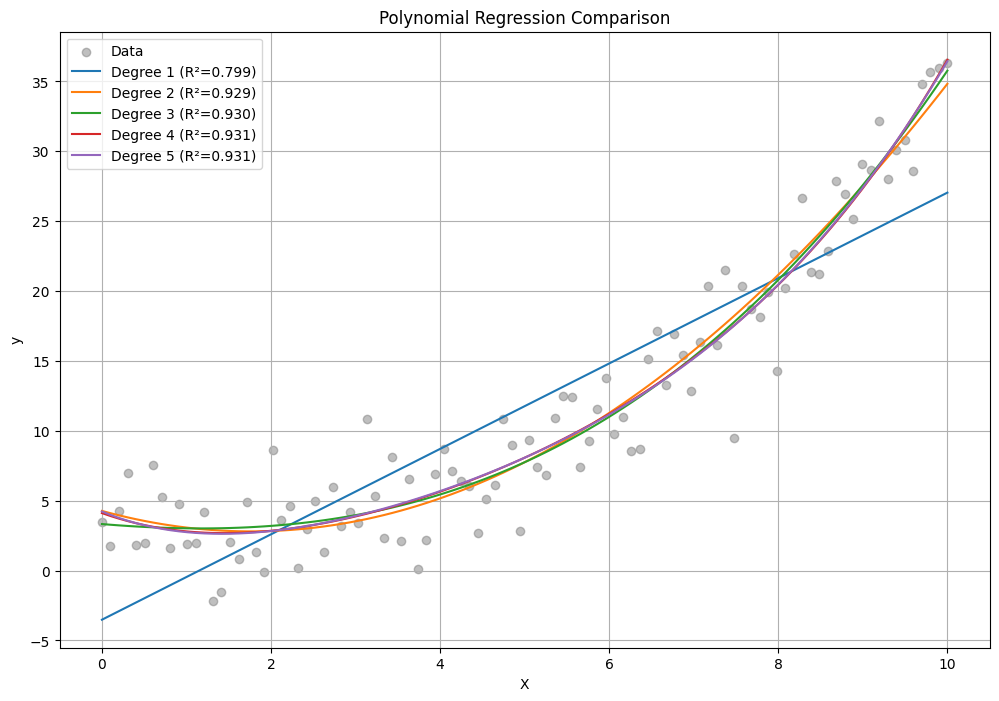

R² Scores by Polynomial Degree:
Degree 1: R² = 0.7991
Degree 2: R² = 0.9286
Degree 3: R² = 0.9301
Degree 4: R² = 0.9309
Degree 5: R² = 0.9309


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Generate synthetic non-linear data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 + 1.5 * X - 0.3 * X**2 + 0.05 * X**3 + np.random.randn(100, 1) * 3

# Degrees to test
degrees = [1, 2, 3, 4, 5]
r2_scores = []

# Plot setup
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')

# Fit and evaluate polynomial models
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    r2 = r2_score(y, y_pred)
    r2_scores.append(r2)
    
    plt.plot(X, y_pred, label=f'Degree {degree} (R²={r2:.3f})')

# Final plot formatting
plt.title('Polynomial Regression Comparison')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Print R² scores
print("R² Scores by Polynomial Degree:")
for degree, score in zip(degrees, r2_scores):
    print(f"Degree {degree}: R² = {score:.4f}")


## Thanks for this assignment
